# Cross-Method Comparison on H2

This benchmark compares three solver families on one shared H2 Hamiltonian:

- `VQE`
- `VarQITE`
- `QPE`

The notebook is meant to be a decision notebook, not a tutorial. It standardizes geometry, reference energy, and reporting so method tradeoffs are visible in one table.

In [1]:
from __future__ import annotations

import time

import matplotlib.pyplot as plt
import pandas as pd
import pennylane as qml

from common.hamiltonian import build_hamiltonian
from qite import run_qite
from qpe import run_qpe
from vqe import run_vqe

In [2]:
molecule = "H2"

H, n_qubits, hf_state = build_hamiltonian(molecule)
exact_spectrum = qml.numpy.linalg.eigvalsh(qml.matrix(H))
exact_ground = float(qml.numpy.min(exact_spectrum))

experiments = [
    (
        "VQE",
        lambda: run_vqe(
            molecule=molecule,
            steps=50,
            stepsize=0.2,
            ansatz_name="UCCSD",
            optimizer_name="Adam",
            plot=False,
            force=False,
        ),
    ),
    (
        "VarQITE",
        lambda: run_qite(
            molecule=molecule,
            steps=50,
            dtau=0.2,
            ansatz_name="UCCSD",
            plot=False,
            show=False,
            force=False,
        ),
    ),
    (
        "QPE",
        lambda: run_qpe(
            molecule=molecule,
            n_ancilla=4,
            t=1.0,
            trotter_steps=2,
            shots=2000,
            plot=False,
            force=False,
        ),
    ),
]

rows = []
for method, runner in experiments:
    start = time.perf_counter()
    result = runner()
    elapsed = time.perf_counter() - start
    rows.append(
        {
            "method": method,
            "energy": float(result["energy"]),
            "exact_ground": exact_ground,
            "abs_error": abs(float(result["energy"]) - exact_ground),
            "elapsed_s": elapsed,
        }
    )

df = pd.DataFrame(rows).sort_values("abs_error")
df

,method,energy,exact_ground,abs_error,elapsed_s
1,VarQITE,-1.137270,-1.13727,4.440892e-16,0.035894
0,VQE,-1.137176,-1.13727,9.379501e-05,0.069197
2,QPE,-1.178097,-1.13727,4.082707e-02,0.035338


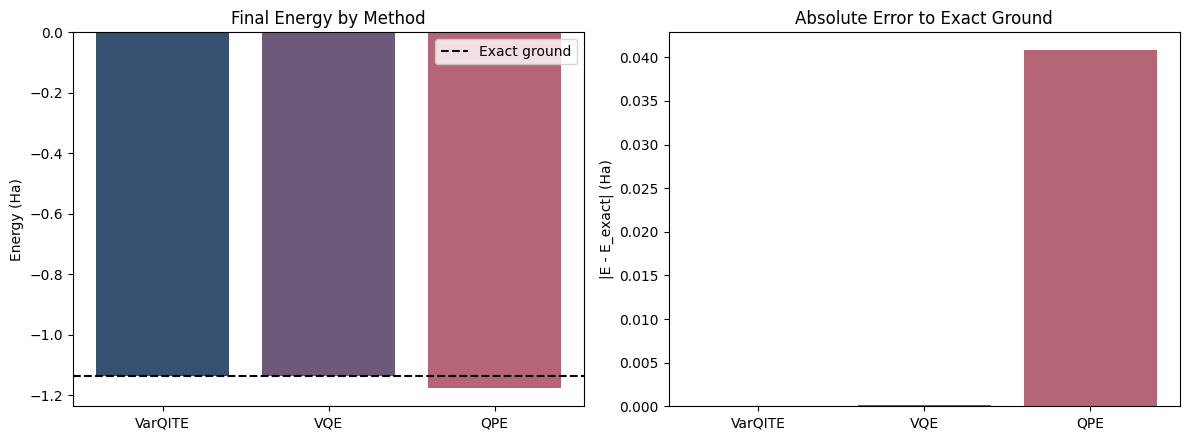

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar(df["method"], df["energy"], color=["#355070", "#6d597a", "#b56576"])
axes[0].axhline(exact_ground, color="black", linestyle="--", label="Exact ground")
axes[0].set_title("Final Energy by Method")
axes[0].set_ylabel("Energy (Ha)")
axes[0].legend()

axes[1].bar(df["method"], df["abs_error"], color=["#355070", "#6d597a", "#b56576"])
axes[1].set_title("Absolute Error to Exact Ground")
axes[1].set_ylabel("|E - E_exact| (Ha)")

plt.tight_layout()
plt.show()

In [4]:
runtime_view = df[["method", "elapsed_s"]].sort_values("elapsed_s")
runtime_view

,method,elapsed_s
2,QPE,0.035338
1,VarQITE,0.035894
0,VQE,0.069197


## Suggested Extensions

- Repeat the table with `force=True` to separate compute cost from cache reuse.
- Add `LiH` once you want to compare how runtime and qubit count scale beyond the smallest benchmark.
- For fairness studies, standardize seeds and plotting policies before comparing noisy variants.